### 1. Bibliotekų importavimas
Šioje celėje importuojamos visos programoje naudojamos bibliotekos. Jos reikalingos darbui su duomenimis, tekstu, failais, grafikais, PyTorch neuroniniais tinklais, duomenų įkėlimu bei modelio vertinimo metrikomis, tokiomis kaip ROUGE ir BERTScore.

In [3]:
# 1. Bibliotekų importavimas

import json
import math
import random
import re
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path
from tqdm import tqdm

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from rouge_score import rouge_scorer
from bert_score import score as bertscore_score

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Konfigūracijos nustatymai
Šioje celėje aprašoma `Config` klasė, kurioje vienoje vietoje laikomi visi pagrindiniai eksperimento nustatymai: duomenų failų keliai, stulpelių pavadinimai, modelio hiperparametrai, mokymo parametrai, generavimo nustatymai ir rezultatų saugojimo vieta.

In [4]:
# 2. Konfigūracijos nustatymai

@dataclass
class Config:
    train_csv: str = r"C:\\bakis\\duomenys_full_anonimized\\samsum-train_anonymized.csv"
    val_csv: str = r"C:\\bakis\\duomenys_full_anonimized\\samsum-test_anonymized.csv"
    test_csv: str = r"C:\\bakis\\duomenys_full_anonimized\\samsum-validation_anonymized.csv"

    text_column: str = "dialogue"
    summary_column: str = "summary"

    output_dir: str = r"C:\\bakis\\Full_anonymization\\encoder_decoder(20260413)"
    use_train_subset: bool = False
    train_subset_size: int = 5000
    subset_random_state: int = 42

    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # tokenizacija / sekų ilgiai
    min_freq: int = 2
    max_generation_len: int = 30 #pabandyti30
    min_generation_len: int = 10 
    beam_size: int = 4
    length_penalty: float = 0.8
    max_src_len: int = 512
    max_tgt_len: int = 40

    # modelis
    d_model: int = 512
    num_heads: int = 8
    num_encoder_layers: int = 6
    num_decoder_layers: int = 6
    d_ff: int = 2048
    dropout: float = 0.1

    # mokymas
    batch_size: int = 18
    num_epochs: int = 25
    lr: float = 1.0
    weight_decay: float = 0.0
    grad_clip: float = 1.0
    warmup_steps: int = 4000

    # early stopping
    patience: int = 4

    # output
    save_predictions_csv: bool = True
    make_plots: bool = True
    dpi: int = 160

    # bertscore
    bertscore_model_type: str = "bert-base-uncased"
    bertscore_lang: str = "en"
    compute_bertscore_on_test: bool = True
    bertscore_batch_size: int = 16

cfg = Config()
cfg


Config(train_csv='C:\\\\bakis\\\\duomenys_full_anonimized\\\\samsum-train_anonymized.csv', val_csv='C:\\\\bakis\\\\duomenys_full_anonimized\\\\samsum-test_anonymized.csv', test_csv='C:\\\\bakis\\\\duomenys_full_anonimized\\\\samsum-validation_anonymized.csv', text_column='dialogue', summary_column='summary', output_dir='C:\\\\bakis\\\\Full_anonymization\\\\encoder_decoder(20260413)', use_train_subset=False, train_subset_size=5000, subset_random_state=42, seed=42, device='cpu', min_freq=2, max_generation_len=30, min_generation_len=10, beam_size=4, length_penalty=0.8, max_src_len=512, max_tgt_len=40, d_model=512, num_heads=8, num_encoder_layers=6, num_decoder_layers=6, d_ff=2048, dropout=0.1, batch_size=18, num_epochs=25, lr=1.0, weight_decay=0.0, grad_clip=1.0, warmup_steps=4000, patience=4, save_predictions_csv=True, make_plots=True, dpi=160, bertscore_model_type='bert-base-uncased', bertscore_lang='en', compute_bertscore_on_test=True, bertscore_batch_size=16)

### 3. Pagalbinės funkcijos tekstui ir aplinkai paruošti
Čia nustatomas atsitiktinumo pradinis taškas, kad rezultatai būtų kuo labiau atkuriami. Taip pat aprašomos pagalbinės funkcijos aplankams sukurti, tekstui normalizuoti, tekstui suskaidyti į žodžius bei suskaičiuoti žodžių kiekį.

In [ ]:
# 3. Pagalbinės funkcijos tekstui ir aplinkai paruošti

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)


def ensure_dir(path):
    p = Path(path)
    p.mkdir(parents=True, exist_ok=True)
    return p


def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text


def simple_tokenize(text):
    text = normalize_text(text).lower()
    # žodžiai + skyryba kaip atskiri tokenai
    return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)


def word_count(text):
    text = normalize_text(text)
    return len(text.split()) if text else 0


def safe_mean(values):
    values = list(values)
    return float(np.mean(values)) if len(values) > 0 else 0.0

### 4. Duomenų įkėlimas ir paruošimas
Šioje celėje aprašomos funkcijos, kurios įkelia CSV failus, patikrina, ar egzistuoja reikalingi dialogo ir santraukos stulpeliai, sutvarko tekstus. Po to įkeliamos treniravimo, validacijos ir testavimo duomenų aibės.

In [ ]:
# 4. Duomenų įkėlimas ir paruošimas

def load_single_dataset(csv_path, cfg):
    df = pd.read_csv(csv_path)

    if cfg.text_column not in df.columns:
        raise ValueError(f"Nerastas teksto stulpelis: {cfg.text_column}")
    if cfg.summary_column not in df.columns:
        raise ValueError(f"Nerastas santraukos stulpelis: {cfg.summary_column}")

    df = df[[cfg.text_column, cfg.summary_column]].copy()
    df[cfg.text_column] = df[cfg.text_column].apply(normalize_text)
    df[cfg.summary_column] = df[cfg.summary_column].apply(normalize_text)

    df = df[
        (df[cfg.text_column] != "") &
        (df[cfg.summary_column] != "")
    ].reset_index(drop=True)

    return df


def maybe_take_train_subset(df, cfg):
    if not cfg.use_train_subset:
        return df.reset_index(drop=True)

    subset_size = min(cfg.train_subset_size, len(df))
    return df.sample(n=subset_size, random_state=cfg.subset_random_state).reset_index(drop=True)


full_train_df = load_single_dataset(cfg.train_csv, cfg)
val_df = load_single_dataset(cfg.val_csv, cfg)
test_df = load_single_dataset(cfg.test_csv, cfg)

train_df = maybe_take_train_subset(full_train_df, cfg)

print("Full train:", len(full_train_df))
print("Used train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Full train: 14731
Used train: 14731
Validation: 819
Test: 818


### 5. Duomenų aibių statistikos išvedimas
Čia apskaičiuojama ir atspausdinama kiekvienos duomenų aibės statistika: kiek yra pavyzdžių, koks vidutinis dialogo ilgis ir koks vidutinis santraukos ilgis.

In [ ]:
# 5. Duomenų aibių statistikos išvedimas

def print_dataset_stats(df, cfg, name):
    source_lengths = df[cfg.text_column].apply(word_count)
    summary_lengths = df[cfg.summary_column].apply(word_count)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Samples: {len(df)}")
    print(f"Avg source words:  {source_lengths.mean():.2f}")
    print(f"Avg summary words: {summary_lengths.mean():.2f}")

print_dataset_stats(train_df, cfg, "TRAIN")
print_dataset_stats(val_df, cfg, "VALIDATION")
print_dataset_stats(test_df, cfg, "TEST")


TRAIN
-----
Samples: 14731
Avg source words:  93.76
Avg summary words: 20.31

VALIDATION
----------
Samples: 819
Avg source words:  95.46
Avg summary words: 20.01

TEST
----
Samples: 818
Avg source words:  91.59
Avg summary words: 20.27


### 6. Žodyno klasė ir specialūs tokenai
Šioje celėje apibrėžiami specialūs tokenai: `<pad>`, `<unk>`, `<bos>` ir `<eos>`. Taip pat sukuriama `Vocab` klasė, kuri iš tekstų sukuria žodyną, priskiria kiekvienam žodžiui indeksą ir leidžia tekstą paversti skaičių seka bei atkurti žodžius iš indeksų.

In [ ]:
# 6. Žodyno klasė ir specialūs tokenai

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"

PAD_IDX = 0
UNK_IDX = 1
BOS_IDX = 2
EOS_IDX = 3


class Vocab:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.token_to_idx = {
            PAD_TOKEN: PAD_IDX,
            UNK_TOKEN: UNK_IDX,
            BOS_TOKEN: BOS_IDX,
            EOS_TOKEN: EOS_IDX,
        }
        self.idx_to_token = {idx: tok for tok, idx in self.token_to_idx.items()}

    def build(self, tokenized_texts):
        counter = Counter()
        for tokens in tokenized_texts:
            counter.update(tokens)

        for token, freq in counter.items():
            if freq >= self.min_freq and token not in self.token_to_idx:
                idx = len(self.token_to_idx)
                self.token_to_idx[token] = idx
                self.idx_to_token[idx] = token

    def encode(self, tokens):
        return [self.token_to_idx.get(tok, UNK_IDX) for tok in tokens]

    def decode(self, ids, skip_special_tokens=True):
        tokens = []
        for idx in ids:
            tok = self.idx_to_token.get(int(idx), UNK_TOKEN)
            if skip_special_tokens and tok in {PAD_TOKEN, BOS_TOKEN, EOS_TOKEN}:
                continue
            tokens.append(tok)
        return tokens

    def __len__(self):
        return len(self.token_to_idx)

### 7. Žodyno sudarymas iš treniravimo duomenų
Čia dialogai ir santraukos suskaidomi į tokenus, apribojamas jų ilgis ir pagal treniravimo duomenis sukuriamas bendras žodynas.

In [ ]:
# 7. Žodyno sudarymas iš treniravimo duomenų

train_source_tokens = [simple_tokenize(x)[:cfg.max_src_len] for x in train_df[cfg.text_column]]
train_target_tokens = [simple_tokenize(x)[:cfg.max_tgt_len] for x in train_df[cfg.summary_column]]

vocab = Vocab(min_freq=cfg.min_freq)
vocab.build(train_source_tokens + train_target_tokens)

print("Vocab size:", len(vocab))

Vocab size: 18157


### 8. Dataset klasė ir DataLoader objektai
Šioje celėje sukuriama `SummarizationDataset` klasė, kuri kiekvieną dialogo ir santraukos porą paverčia modelio įvesčiai tinkamu formatu. Taip pat aprašoma `collate_fn` funkcija, kuri suvienodina sekų ilgius naudojant padding, ir sukuriami `DataLoader` objektai treniravimui, validacijai bei testavimui.

In [ ]:
# 8. Dataset klasė ir DataLoader objektai

class SummarizationDataset(Dataset):
    def __init__(self, df, vocab, cfg):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.cfg = cfg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        src_text = row[self.cfg.text_column]
        tgt_text = row[self.cfg.summary_column]

        src_tokens = simple_tokenize(src_text)[:self.cfg.max_src_len]
        tgt_tokens = simple_tokenize(tgt_text)[:self.cfg.max_tgt_len]

        src_ids = self.vocab.encode(src_tokens)
        tgt_ids = [BOS_IDX] + self.vocab.encode(tgt_tokens) + [EOS_IDX]

        return {
            "source_text": src_text,
            "target_text": tgt_text,
            "src_ids": src_ids,
            "tgt_ids": tgt_ids,
        }


def pad_sequences(sequences, pad_value=0):
    max_len = max(len(seq) for seq in sequences)
    padded = []
    lengths = []
    for seq in sequences:
        lengths.append(len(seq))
        padded.append(seq + [pad_value] * (max_len - len(seq)))
    return torch.tensor(padded, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)


def collate_fn(batch):
    src_ids = [item["src_ids"] for item in batch]
    tgt_ids = [item["tgt_ids"] for item in batch]

    src_padded, src_lengths = pad_sequences(src_ids, pad_value=PAD_IDX)
    tgt_padded, tgt_lengths = pad_sequences(tgt_ids, pad_value=PAD_IDX)

    return {
        "source_texts": [item["source_text"] for item in batch],
        "target_texts": [item["target_text"] for item in batch],
        "src_ids": src_padded,
        "src_lengths": src_lengths,
        "tgt_ids": tgt_padded,
        "tgt_lengths": tgt_lengths,
    }


train_dataset = SummarizationDataset(train_df, vocab, cfg)
val_dataset = SummarizationDataset(val_df, vocab, cfg)
test_dataset = SummarizationDataset(test_df, vocab, cfg)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_fn)

### 9. Transformer encoder-decoder modelio architektūra
Šioje dalyje aprašoma pagrindinė santraukų generavimo modelio architektūra. Modelis naudoja tokenų embeddingus, pozicinį kodavimą, Transformer encoder ir decoder blokus, kaukes bei generavimo funkciją. Encoder dalis apdoroja dialogą, o decoder dalis žingsnis po žingsnio generuoja santrauką.

In [ ]:
# 9. Transformer encoder-decoder modelio architektūra

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None, return_attention=False):
        batch_size = query.size(0)

        Q = self.q_proj(query)
        K = self.k_proj(key)
        V = self.v_proj(value)

        Q = Q.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        context = torch.matmul(attn, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        out = self.out_proj(context)

        if return_attention:
            return out, attn
        return out


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        attn_out = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn_out))

        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, src_mask, return_attention=False):
        self_attn_out = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(self_attn_out))

        if return_attention:
            cross_attn_out, cross_attn_weights = self.cross_attn(
                x, enc_out, enc_out, src_mask, return_attention=True
            )
        else:
            cross_attn_out = self.cross_attn(x, enc_out, enc_out, src_mask)
            cross_attn_weights = None

        x = self.norm2(x + self.dropout(cross_attn_out))

        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))

        if return_attention:
            return x, cross_attn_weights
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(d_model)

    def forward(self, src_ids, src_mask):
        x = self.embedding(src_ids) * self.scale
        x = self.pos_encoding(x)

        for layer in self.layers:
            x = layer(x, src_mask)

        return x


class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(d_model)

    def forward(self, tgt_ids, enc_out, tgt_mask, src_mask, return_attention=False):
        x = self.embedding(tgt_ids) * self.scale
        x = self.pos_encoding(x)

        last_cross_attn = None

        for layer in self.layers:
            if return_attention:
                x, last_cross_attn = layer(
                    x, enc_out, tgt_mask, src_mask, return_attention=True
                )
            else:
                x = layer(x, enc_out, tgt_mask, src_mask)

        logits = self.fc_out(x)

        if return_attention:
            return logits, last_cross_attn
        return logits


class TransformerSummarizer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_encoder_layers, num_decoder_layers, d_ff, dropout=0.1):
        super().__init__()
        self.encoder = TransformerEncoder(
            vocab_size=vocab_size,
            d_model=d_model,
            num_layers=num_encoder_layers,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout,
        )

        self.decoder = TransformerDecoder(
            vocab_size=vocab_size,
            d_model=d_model,
            num_layers=num_decoder_layers,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout,
        )

    def make_src_mask(self, src_ids):
        return (src_ids != PAD_IDX).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt_ids):
        batch_size, tgt_len = tgt_ids.shape

        pad_mask = (tgt_ids != PAD_IDX).unsqueeze(1).unsqueeze(2)
        causal_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt_ids.device)).bool()
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(1)

        return pad_mask & causal_mask

    def forward(self, src_ids, tgt_ids, return_attention=False):
        src_mask = self.make_src_mask(src_ids)
        tgt_mask = self.make_tgt_mask(tgt_ids)

        enc_out = self.encoder(src_ids, src_mask)

        if return_attention:
            logits, cross_attn = self.decoder(
                tgt_ids, enc_out, tgt_mask, src_mask, return_attention=True
            )
            return logits, cross_attn

        logits = self.decoder(tgt_ids, enc_out, tgt_mask, src_mask)
        return logits
    
    @torch.no_grad()
    def generate(
        self,
        src_ids,
        max_len=50,
        min_len=10,
        beam_size=4,
        length_penalty=0.8,
        no_repeat_bigram=True
    ):
        self.eval()
        batch_size = src_ids.size(0)

        src_mask = self.make_src_mask(src_ids)
        enc_out = self.encoder(src_ids, src_mask)

        all_sequences = []

        for b in range(batch_size):
            single_enc_out = enc_out[b:b+1]
            single_src_mask = src_mask[b:b+1]

            beams = [([BOS_IDX], 0.0, False)]  # (tokens, score, finished)

            for step in range(max_len):
                new_beams = []

                for seq, score, finished in beams:
                    if finished:
                        new_beams.append((seq, score, finished))
                        continue

                    tgt = torch.tensor(seq, dtype=torch.long, device=src_ids.device).unsqueeze(0)
                    tgt_mask = self.make_tgt_mask(tgt)

                    logits = self.decoder(tgt, single_enc_out, tgt_mask, single_src_mask)
                    next_token_logits = logits[:, -1, :].squeeze(0).clone()

                    if step < min_len:
                        next_token_logits[EOS_IDX] = -1e9

                    if no_repeat_bigram and len(seq) >= 2:
                        last_token = seq[-1]
                        used_bigrams = set((seq[i], seq[i + 1]) for i in range(len(seq) - 1))

                        for token_id in range(next_token_logits.size(0)):
                            if (last_token, token_id) in used_bigrams:
                                next_token_logits[token_id] = -1e9

                    log_probs = torch.log_softmax(next_token_logits, dim=-1)
                    topk_log_probs, topk_indices = torch.topk(log_probs, beam_size)

                    for k in range(beam_size):
                        token_id = topk_indices[k].item()
                        token_score = topk_log_probs[k].item()

                        new_seq = seq + [token_id]
                        new_score = score + token_score
                        new_finished = (token_id == EOS_IDX)

                        new_beams.append((new_seq, new_score, new_finished))

                beams = sorted(
                    new_beams,
                    key=lambda x: x[1] / ((len(x[0]) ** length_penalty) if len(x[0]) > 0 else 1.0),
                    reverse=True
                )[:beam_size]

                if all(finished for _, _, finished in beams):
                    break

            best_seq = beams[0][0]
            all_sequences.append(best_seq)

        max_out_len = max(len(seq) for seq in all_sequences)
        padded = []

        for seq in all_sequences:
            padded_seq = seq + [PAD_IDX] * (max_out_len - len(seq))
            padded.append(padded_seq)

        return torch.tensor(padded, dtype=torch.long, device=src_ids.device)

### 10. Modelio, nuostolio funkcijos ir optimizatoriaus sukūrimas
Čia sukuriamas Transformer santraukų modelis pagal konfigūracijoje nurodytus parametrus. Taip pat apibrėžiama nuostolio funkcija `CrossEntropyLoss`, ignoruojanti padding tokenus, ir `Adam` optimizatorius, kuris mokymo metu atnaujina modelio svorius.

In [ ]:
# 10. Modelio, nuostolio funkcijos ir optimizatoriaus sukūrimas

model = TransformerSummarizer(
    vocab_size=len(vocab),
    d_model=cfg.d_model,
    num_heads=cfg.num_heads,
    num_encoder_layers=cfg.num_encoder_layers,
    num_decoder_layers=cfg.num_decoder_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
).to(cfg.device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.05)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=cfg.lr,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=cfg.weight_decay
)

print(model)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_parameters(model))

TransformerSummarizer(
  (encoder): TransformerEncoder(
    (embedding): Embedding(18157, 512, padding_idx=0)
    (pos_encoding): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-5): 6 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (q_proj): Linear(in_features=512, out_features=512, bias=True)
          (k_proj): Linear(in_features=512, out_features=512, bias=True)
          (v_proj): Linear(in_features=512, out_features=512, bias=True)
          (out_proj): Linear(in_features=512, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): PositionwiseFeedForward(
          (net): Sequential(
            (0): Linear(in_features=512, out_features=2048, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=2048, out_features=512, bias=True)
          )
        )
        (norm1): LayerNorm((512,), eps=1e

### 11. Mokymosi greičio planuoklis
Šioje celėje aprašomas `NoamScheduler`, kuris dinamiškai keičia mokymosi greitį. Pradžioje mokymosi greitis palaipsniui didinamas, o vėliau mažinamas. 

In [ ]:
# 11. Mokymosi greičio planuoklis

class NoamScheduler:
    def __init__(self, optimizer, d_model, warmup_steps):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0

    def step(self):
        self.step_num += 1
        lr = (self.d_model ** -0.5) * min(
            self.step_num ** -0.5,
            self.step_num * (self.warmup_steps ** -1.5)
        )

        for param_group in self.optimizer.param_groups:
            param_group["lr"] = lr

        self.optimizer.step()

    def zero_grad(self):
        self.optimizer.zero_grad()

    def get_last_lr(self):
        return self.optimizer.param_groups[0]["lr"]

scheduler = NoamScheduler(
    optimizer=optimizer,
    d_model=cfg.d_model,
    warmup_steps=cfg.warmup_steps
)

### 12. Vienos epochos mokymo funkcija
Ši funkcija atlieka vieną modelio mokymo epochą. Kiekviename batch'e paruošiama decoder įvestis ir tikslinis atsakymas, atliekamas forward pass, apskaičiuojamas loss, atliekamas gradientų skaičiavimas, gradientų apribojimas ir modelio svorių atnaujinimas.

In [ ]:
# 12. Vienos epochos mokymo funkcija

def train_one_epoch(model, loader, scheduler, criterion, device, grad_clip=1.0):
    model.train()
    total_loss = 0.0

    for batch_idx, batch in enumerate(loader, start=1):
        src_ids = batch["src_ids"].to(device)
        tgt_ids = batch["tgt_ids"].to(device)

        decoder_input = tgt_ids[:, :-1]
        target_output = tgt_ids[:, 1:]

        scheduler.zero_grad()

        outputs = model(
            src_ids=src_ids,
            tgt_ids=decoder_input
        )

        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            target_output.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scheduler.step()

        total_loss += loss.item()

        if batch_idx % 20 == 0 or batch_idx == len(loader):
            print(
                f"    batch {batch_idx}/{len(loader)} | "
                f"loss={loss.item():.4f} | lr={scheduler.get_last_lr():.8f}"
            )

    return total_loss / max(len(loader), 1)

### 13. Validacijos nuostolio skaičiavimas
Ši funkcija įvertina modelį validacijos arba testavimo duomenyse neskaičiuojant gradientų. Ji apskaičiuoja vidutinį loss, kuris parodo, kaip gerai modelis veikia su duomenimis, kurių jis tiesiogiai nemoko.

In [ ]:
# 13. Validacijos nuostolio skaičiavimas

@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        src_ids = batch["src_ids"].to(device)
        tgt_ids = batch["tgt_ids"].to(device)

        decoder_input = tgt_ids[:, :-1]
        target_output = tgt_ids[:, 1:]

        outputs = model(
            src_ids=src_ids,
            tgt_ids=decoder_input
        )

        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            target_output.reshape(-1)
        )

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)

### 14. ROUGE metrikų skaičiavimas
Šioje celėje aprašoma funkcija, kuri palygina modelio sugeneruotas santraukas su etaloninėmis santraukomis. ROUGE-1, ROUGE-2 ir ROUGE-L metrikos parodo, kiek žodžių, žodžių porų ar ilgiausių bendrų sekų sutampa tarp prognozės ir tikros santraukos.

In [ ]:
# 14. ROUGE metrikų skaičiavimas

def compute_rouge(pred_df):
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

    rouge1_p, rouge1_r, rouge1_f = [], [], []
    rouge2_p, rouge2_r, rouge2_f = [], [], []
    rougeL_p, rougeL_r, rougeL_f = [], [], []

    for _, row in pred_df.iterrows():
        reference = row["reference_summary"]
        prediction = row["predicted_summary"]

        scores = scorer.score(reference, prediction)

        r1 = scores["rouge1"]
        r2 = scores["rouge2"]
        rl = scores["rougeL"]

        rouge1_p.append(r1.precision)
        rouge1_r.append(r1.recall)
        rouge1_f.append(r1.fmeasure)

        rouge2_p.append(r2.precision)
        rouge2_r.append(r2.recall)
        rouge2_f.append(r2.fmeasure)

        rougeL_p.append(rl.precision)
        rougeL_r.append(rl.recall)
        rougeL_f.append(rl.fmeasure)

    pred_df = pred_df.copy()
    pred_df["rouge1_precision"] = rouge1_p
    pred_df["rouge1_recall"] = rouge1_r
    pred_df["rouge1_f1"] = rouge1_f

    pred_df["rouge2_precision"] = rouge2_p
    pred_df["rouge2_recall"] = rouge2_r
    pred_df["rouge2_f1"] = rouge2_f

    pred_df["rougeL_precision"] = rougeL_p
    pred_df["rougeL_recall"] = rougeL_r
    pred_df["rougeL_f1"] = rougeL_f

    return pred_df

### 15. BERTScore metrikos skaičiavimas
Čia apskaičiuojamas BERTScore, kuris vertina ne tik tikslų žodžių sutapimą, bet ir semantinį panašumą tarp sugeneruotos ir etaloninės santraukos. Ši metrika padeda įvertinti, ar modelio santrauka prasmiškai panaši į teisingą atsakymą.

In [ ]:
# 15. BERTScore metrikos skaičiavimas

def compute_bertscore(pred_df, cfg):
    refs = pred_df["reference_summary"].fillna("").astype(str).tolist()
    preds = pred_df["predicted_summary"].fillna("").astype(str).tolist()

    P, R, F1 = bertscore_score(
        preds,
        refs,
        lang=cfg.bertscore_lang,
        model_type=cfg.bertscore_model_type,
        batch_size=cfg.bertscore_batch_size,
        verbose=True,
        device=cfg.device
    )

    pred_df["bertscore_precision"] = P.cpu().numpy()
    pred_df["bertscore_recall"] = R.cpu().numpy()
    pred_df["bertscore_f1"] = F1.cpu().numpy()

    return pred_df

### 16. Santraukų generavimas modeliu
Šioje celėje aprašomos funkcijos, kurios modelio sugeneruotus tokenų indeksus paverčia tekstu ir sugeneruoja santraukas visai duomenų aibei. Rezultatai saugomi lentelėje kartu su originaliu tekstu ir etalonine santrauka.

In [ ]:
# 16. Santraukų generavimas modeliu

@torch.no_grad()
def decode_generated_tokens(token_ids, vocab):
    tokens = []
    for idx in token_ids:
        idx = int(idx)
        if idx == EOS_IDX:
            break
        if idx in {PAD_IDX, BOS_IDX}:
            continue
        tokens.append(vocab.idx_to_token.get(idx, UNK_TOKEN))
    return " ".join(tokens).strip()


@torch.no_grad()
def generate_predictions(model, loader, vocab, cfg, split_name):
    model.eval()
    rows = []

    for batch in loader:
        src_ids = batch["src_ids"].to(cfg.device)

        generated = model.generate(
            src_ids=src_ids,
            max_len=cfg.max_generation_len,
            min_len=cfg.min_generation_len,
            beam_size=cfg.beam_size,
            length_penalty=cfg.length_penalty,
            no_repeat_bigram=True
        )

        for i in range(src_ids.size(0)):
            prediction = decode_generated_tokens(generated[i].tolist(), vocab)

            source_text = batch["source_texts"][i]
            reference = batch["target_texts"][i]

            rows.append({
                "split": split_name,
                "id": len(rows),
                "source_text": source_text,
                "reference_summary": reference,
                "predicted_summary": prediction,
                "source_words": word_count(source_text),
                "reference_words": word_count(reference),
                "prediction_words": word_count(prediction),
            })

    return pd.DataFrame(rows)

### 17. Bendrų rezultatų metrikų sudarymas
Ši funkcija iš visų prognozių apskaičiuoja suvestines metrikas: vidutines ROUGE reikšmes, BERTScore reikšmes, įvesties ir santraukų ilgius.

In [ ]:
# 17. Bendrų rezultatų metrikų sudarymas

def build_metrics(pred_df):
    metrics = {
        "num_samples": int(len(pred_df)),
        "rouge1_f1_mean": safe_mean(pred_df["rouge1_f1"].values),
        "rouge2_f1_mean": safe_mean(pred_df["rouge2_f1"].values),
        "rougeL_f1_mean": safe_mean(pred_df["rougeL_f1"].values),

        "rouge1_precision_mean": safe_mean(pred_df["rouge1_precision"].values),
        "rouge1_recall_mean": safe_mean(pred_df["rouge1_recall"].values),

        "rouge2_precision_mean": safe_mean(pred_df["rouge2_precision"].values),
        "rouge2_recall_mean": safe_mean(pred_df["rouge2_recall"].values),

        "rougeL_precision_mean": safe_mean(pred_df["rougeL_precision"].values),
        "rougeL_recall_mean": safe_mean(pred_df["rougeL_recall"].values),

        "source_words_mean": safe_mean(pred_df["source_words"].values),
        "reference_words_mean": safe_mean(pred_df["reference_words"].values),
        "prediction_words_mean": safe_mean(pred_df["prediction_words"].values),
    }

    if "bertscore_precision" in pred_df.columns:
        metrics["bertscore_precision_mean"] = float(pred_df["bertscore_precision"].mean())
        metrics["bertscore_recall_mean"] = float(pred_df["bertscore_recall"].mean())
        metrics["bertscore_f1_mean"] = float(pred_df["bertscore_f1"].mean())
        
    return metrics


def print_metrics(metrics, split_name):
    print(f"\n===== {split_name.upper()} METRICS =====")
    print(f"Samples:               {metrics['num_samples']}")
    print(f"ROUGE-1 F1:            {metrics['rouge1_f1_mean']:.4f}")
    print(f"ROUGE-2 F1:            {metrics['rouge2_f1_mean']:.4f}")
    print(f"ROUGE-L F1:            {metrics['rougeL_f1_mean']:.4f}")
    print(f"ROUGE-1 Precision:     {metrics['rouge1_precision_mean']:.4f}")
    print(f"ROUGE-1 Recall:        {metrics['rouge1_recall_mean']:.4f}")
    print(f"ROUGE-2 Precision:     {metrics['rouge2_precision_mean']:.4f}")
    print(f"ROUGE-2 Recall:        {metrics['rouge2_recall_mean']:.4f}")
    print(f"ROUGE-L Precision:     {metrics['rougeL_precision_mean']:.4f}")
    print(f"ROUGE-L Recall:        {metrics['rougeL_recall_mean']:.4f}")
    print(f"Avg source words:      {metrics['source_words_mean']:.2f}")
    print(f"Avg reference words:   {metrics['reference_words_mean']:.2f}")
    print(f"Avg prediction words:  {metrics['prediction_words_mean']:.2f}")

### 18. Rezultatų saugojimo ir grafikų funkcijos
Šioje dalyje aprašomos funkcijos, kurios išsaugo lenteles, metrikas ir mokymo grafiką į failus. 

In [ ]:
# 18. Rezultatų saugojimo ir grafikų funkcijos

def save_dataframe(df, path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        df.to_csv(path, index=False, encoding="utf-8")
    elif path.suffix.lower() == ".json":
        df.to_json(path, orient="records", force_ascii=False, indent=2)
    else:
        raise ValueError(f"Nepalaikomas failo tipas: {path}")


def save_metrics(metrics, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)


def save_training_plot(history, output_path, dpi=160):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training history")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()

### 19. Rezultatų aplankų paruošimas
Čia sukuriamas pagrindinis rezultatų aplankas ir atskiras modelio aplankas. Juose vėliau bus saugomas geriausias modelis, konfigūracija, prognozės, metrikos ir grafikai.

In [ ]:
# 19. Rezultatų aplankų paruošimas

output_dir = ensure_dir(cfg.output_dir)
model_dir = ensure_dir(output_dir / "model")

### 20. Modelio mokymo ciklas
Šioje celėje vykdomas pagrindinis mokymo procesas per kelias epochas. Kiekvienoje epochoje modelis mokomas su treniravimo duomenimis, vertinamas validacijos duomenyse, saugomas geriausias modelis ir taikomas ankstyvas sustabdymas, jei validacijos rezultatai nebegerėja.

In [ ]:
# 20. Modelio mokymo ciklas



history = {
    "train_loss": [],
    "val_loss": [],
    "epoch_time_sec": []
}

best_val_loss = float("inf")
best_epoch = -1
patience_counter = 0

start_time = time.time()

print("START TRAINING")

for epoch in range(1, cfg.num_epochs + 1):
    epoch_start = time.time()

    print(f"\n===== Epoch {epoch}/{cfg.num_epochs} =====")

    train_loss = train_one_epoch(
    model=model,
    loader=train_loader,
    scheduler=scheduler,
    criterion=criterion,
    device=cfg.device,
    grad_clip=cfg.grad_clip,
    )

    val_loss = evaluate_loss(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=cfg.device,
    )

    epoch_time = time.time() - epoch_start

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["epoch_time_sec"].append(epoch_time)

    print(f"Epoch {epoch:02d}/{cfg.num_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | time={epoch_time:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0

        checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": asdict(cfg),
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "history": history,
        "vocab_token_to_idx": vocab.token_to_idx,
        }

        torch.save(checkpoint, model_dir / "best_model.pt")
        print("  -> best model saved")
    else:
        patience_counter += 1
        print(f"  -> no improvement ({patience_counter}/{cfg.patience})")

        if patience_counter >= cfg.patience:
            print("Early stopping triggered.")
            break

total_time_sec = time.time() - start_time

training_summary = {
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "epochs_completed": len(history["train_loss"]),
    "total_training_time_sec": total_time_sec,
    "total_training_time_min": total_time_sec / 60,
    "history": history,
}

with open(model_dir / "training_summary.json", "w", encoding="utf-8") as f:
    json.dump(training_summary, f, ensure_ascii=False, indent=2)

print(f"\nTotal training time: {total_time_sec / 60:.2f} min")
print(f"Training summary saved to: {output_dir / 'training_summary.json'}")

save_training_plot(history, model_dir / "training_history.png", dpi=cfg.dpi)

START TRAINING

===== Epoch 1/25 =====
    batch 20/819 | loss=9.6360 | lr=0.00000349


KeyboardInterrupt: 

### 21. Geriausio išsaugoto modelio įkėlimas
Po mokymo įkeliamas geriausias modelio checkpoint failas. Atkuriamas žodynas ir modelio svoriai, kad toliau būtų galima generuoti santraukas bei atlikti galutinį vertinimą su validacijos ir testavimo duomenimis.

In [ ]:
# 21. Geriausio išsaugoto modelio įkėlimas

checkpoint = torch.load(model_dir / "best_model.pt", map_location=cfg.device)

loaded_vocab = Vocab(min_freq=cfg.min_freq)
loaded_vocab.token_to_idx = checkpoint["vocab_token_to_idx"]
loaded_vocab.idx_to_token = {idx: tok for tok, idx in loaded_vocab.token_to_idx.items()}

loaded_model = TransformerSummarizer(
    vocab_size=len(loaded_vocab),
    d_model=cfg.d_model,
    num_heads=cfg.num_heads,
    num_encoder_layers=cfg.num_encoder_layers,
    num_decoder_layers=cfg.num_decoder_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
).to(cfg.device)

loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

print("Loaded best model from epoch:", checkpoint["best_epoch"])
print("Best val loss:", checkpoint["best_val_loss"])

C:\Users\User\AppData\Local\Temp\ipykernel_18984\1914260880.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_dir / "best_model.pt", map_loca

Loaded best model from epoch: 11
Best val loss: 3.98522863180741


### 22. Konfigūracijos išsaugojimas
Šioje celėje visi eksperimento nustatymai išsaugomi į `config.json` failą. Tai svarbu rezultatų atkuriamumui, nes vėliau galima tiksliai matyti, su kokiais parametrais buvo mokytas modelis.

In [ ]:
# 22. Konfigūracijos išsaugojimas

output_dir = Path(cfg.output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

with open(output_dir / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(cfg), f, ensure_ascii=False, indent=2)

### 23. Prognozių generavimas ir vertinimas validacijos bei testavimo aibėse
Čia modelis naudojamas santraukoms sugeneruoti validacijos ir testavimo duomenims. Sugeneruotos santraukos įvertinamos ROUGE ir, jei nurodyta, BERTScore metrikomis. Rezultatai išsaugomi atskiruose aplankuose.

In [ ]:
# 23. Prognozių generavimas ir vertinimas validacijos bei testavimo aibėse

all_results = {}

split_map = {
    #"train": train_loader,
    "val": val_loader,
    "test": test_loader,
}

for split_name, loader in split_map.items():
    print(f"\nProcessing {split_name}...")

    split_dir = ensure_dir(output_dir / split_name)

    pred_df = generate_predictions(
        model=loaded_model,
        loader=loader,
        vocab=loaded_vocab,
        cfg=cfg,
        split_name=split_name
    )

    pred_df = compute_rouge(pred_df)

    if split_name == "test" and cfg.compute_bertscore_on_test:
        pred_df = compute_bertscore(pred_df, cfg)

    metrics = build_metrics(pred_df)

    pred_df.to_csv(split_dir / "predictions.csv", index=False, encoding="utf-8")

    with open(split_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)

    print(metrics)

print("\nDone.")


Processing val...


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


### 24. Patikrinimas, ar testavimo prognozių failas sukurtas
Šioje celėje sudaromas kelias iki `predictions.csv` failo ir patikrinama, ar šis failas egzistuoja. Tai paprastas kontrolinis žingsnis prieš skaitant išsaugotas prognozes.

In [ ]:
# 24. Patikrinimas, ar testavimo prognozių failas sukurtas

p = output_dir / "test" / "predictions.csv"
print(p)
print(p.exists())

C:\bakis\Full_anonymization\encoder_decoder(20260413)\test\predictions.csv
True


### 25. Testavimo prognozių peržiūra
Čia įkeliamos testavimo aibės prognozės ir parodomos pirmos kelios eilutės. 

In [ ]:
# 25. Testavimo prognozių peržiūra

test_predictions = pd.read_csv(Path(cfg.output_dir) / "test" / "predictions.csv")
test_predictions[["source_text", "reference_summary", "predicted_summary", "rouge1_f1", "rougeL_f1", "bertscore_f1"]].head(10)

,source_text,reference_summary,predicted_summary,rouge1_f1,rougeL_f1,bertscore_f1
0,"Person1: Hey, do you have Betty's number? Pers...",Person1 needs Betty's number but Person2 doesn...,person1 and person2 are talking about the curr...,0.160000,0.160000,0.534315
1,Person1: MACHINE! Person2: That's so gr8! Pers...,Person1 and Person2 are going to watch a stand...,person1 and person2 are going to watch a stand...,0.880000,0.880000,0.835577
2,"Person1: Babe, can you help me with something?...",Person1 can't decide which trousers to buy. Pe...,person1 wants to buy a new dress and asks for ...,0.238095,0.238095,0.658255
3,"Person1: hey babe, what do you want for dinner...",Person2 will be home soon and she will let Per...,person1 will pick up person2 and they ' ll hav...,0.333333,0.166667,0.660324
4,"Person1: Hi , are you in Warsaw Person2: yes, ...",Person2 is in Warsaw. Person1 and Person2 has ...,person1 and person2 are going to the beach on ...,0.343750,0.250000,0.715488
5,"Person1: Hey guys, what are we doing with the ...",Person2 has the keys to the apartment. Person1...,"person1 , person2 , person3 and person4 are me...",0.354430,0.253165,0.652759
6,Person1: Know any good sites to buy clothes fr...,Person2 provides Person1 with websites selling...,person1 wants to buy 2 tickets for person2 ' s...,0.146341,0.146341,0.567736
7,Person1: I'm so bloody tired. Falling asleep a...,Person1 and Person2 are bored at work and have...,person1 and person2 are going to the gym at 4 ...,0.500000,0.500000,0.686645
8,"Person1: I am in town, shopping. They have nic...","Person1 wants to buy Person2 a scarf, but he d...",person1 and person2 are going shopping for the...,0.157895,0.105263,0.501990
9,Person1: hey eric Person2: yeah man Person1: s...,Person2 doesn't know if his parents let him go...,person1 ' s parents are coming to london . per...,0.400000,0.171429,0.662063


### 26. Funkcijos modelio įkėlimui ir vieno teksto santraukos generavimui
Šioje celėje sukuriamos pagalbinės funkcijos, leidžiančios išsaugotą modelį įkelti iš failo ir panaudoti jį vienam naujam dialogui sutrumpinti. 

In [ ]:
# 26. Funkcijos modelio įkėlimui ir vieno teksto santraukos generavimui

def load_saved_transformer_model(model_path, cfg):
    checkpoint = torch.load(model_path, map_location=cfg.device)

    vocab = Vocab(min_freq=cfg.min_freq)
    vocab.token_to_idx = checkpoint["vocab_token_to_idx"]
    vocab.idx_to_token = {idx: tok for tok, idx in vocab.token_to_idx.items()}

    model = TransformerSummarizer(
        vocab_size=len(vocab),
        d_model=cfg.d_model,
        num_heads=cfg.num_heads,
        num_encoder_layers=cfg.num_encoder_layers,
        num_decoder_layers=cfg.num_decoder_layers,
        d_ff=cfg.d_ff,
        dropout=cfg.dropout,
    ).to(cfg.device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model, vocab, checkpoint


@torch.no_grad()
def predict_with_saved_transformer(model_path, text, cfg):
    model, vocab, checkpoint = load_saved_transformer_model(model_path, cfg)

    tokens = simple_tokenize(text)[:cfg.max_src_len]
    src_ids = vocab.encode(tokens)
    src_tensor = torch.tensor(src_ids, dtype=torch.long, device=cfg.device).unsqueeze(0)

    generated = model.generate(
        src_ids=src_tensor,
        max_len=cfg.max_generation_len,
        min_len=cfg.min_generation_len,
        beam_size=cfg.beam_size,
        length_penalty=cfg.length_penalty,
        no_repeat_bigram=True
    )
    prediction = decode_generated_tokens(generated[0].tolist(), vocab)

    return prediction

### 27. Modelio išbandymas su pavyzdiniu dialogu
Čia pateikiamas trumpas dialogo pavyzdys anglų kalba. Išsaugotas modelis sugeneruoja šio dialogo santrauką, o rezultatas atspausdinamas ekrane.

In [ ]:
# 27. Modelio išbandymas su pavyzdiniu dialogu

sample_text = """Person1: Are we still meeting tomorrow?
Person2: Yes, at 10 in the library.
Person1: Great, I will bring the notes.
Person2: Perfect, see you there."""

summary = predict_with_saved_transformer(
    Path(cfg.output_dir) / "model" / "best_model.pt",
    sample_text,
    cfg
)
print(summary)

C:\Users\User\AppData\Local\Temp\ipykernel_18984\4077928791.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=cfg.device)


person1 and person2 are meeting at the pub tomorrow .


### 28. Modelio parametrų skaičiavimas
Čia apskaičiuojamas bendras modelio parametrų skaičius, mokomų parametrų skaičius ir nemokomų parametrų skaičius. 

In [ ]:
# 28. Modelio parametrų skaičiavimas

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable = total - trainable
    return total, trainable, non_trainable

total, trainable, non_trainable = count_parameters(model)

print(f"Iš viso parametrų: {total:,}")
print(f"Mokomų parametrų: {trainable:,}")
print(f"Nemokomų parametrų: {non_trainable:,}")

Iš viso parametrų: 75,192,044
Mokomų parametrų: 75,192,044
Nemokomų parametrų: 0


### 29. Geriausių ir blogiausių pavyzdžių analizė
Šioje celėje aprašoma funkcija, kuri pagal pasirinktą metriką parodo geriausiai ir blogiausiai modelio sugeneruotas santraukas. 

In [ ]:
# 29. Geriausių ir blogiausių pavyzdžių analizė

def show_best_worst_examples(df, metric="rougeL_f1", n=5,
                             source_col="source_text",
                             ref_col="reference_summary",
                             pred_col="predicted_summary"):
    df_sorted = df.sort_values(by=metric, ascending=False)

    best = df_sorted.head(n)
    worst = df_sorted.tail(n)

    print("\n" + "=" * 80)
    print("BEST EXAMPLES")
    print("=" * 80)

    for _, row in best.iterrows():
        print(f"\nID: {row['id']}")
        print(f"Score ({metric}) = {row[metric]:.4f}")

        print("\nSOURCE:")
        print(row[source_col])

        print("\nREFERENCE:")
        print(row[ref_col])

        print("\nPREDICTION:")
        print(row[pred_col])

        print("\n" + "-" * 80)

    print("\n" + "=" * 80)
    print("WORST EXAMPLES")
    print("=" * 80)

    for _, row in worst.iterrows():
        print(f"\nID: {row['id']}")
        print(f"Score ({metric}) = {row[metric]:.4f}")

        print("\nSOURCE:")
        print(row[source_col])

        print("\nREFERENCE:")
        print(row[ref_col])

        print("\nPREDICTION:")
        print(row[pred_col])

        print("\n" + "-" * 80)

test_predictions = pd.read_csv(Path(cfg.output_dir) / "test" / "predictions.csv")

show_best_worst_examples(
    test_predictions,
    metric="bertscore_f1",
    n=3
)


BEST EXAMPLES

ID: 156
Score (bertscore_f1) = 1.0000

SOURCE:
Person1: Let's go for a beer Person2: Now? Person1: Yes Person3: Ok

REFERENCE:
Person1, Person2 and Person3 will go for a beer.

PREDICTION:
person1 , person2 and person3 will go for a beer .

--------------------------------------------------------------------------------

ID: 533
Score (bertscore_f1) = 0.9754

SOURCE:
Person1: Where are we meeting? Person2: at the entrance Person3: yes, it's the best place. We would't find each other inside, it'll be too crowded Person1: ok!

REFERENCE:
Person1, Person2 and Person3 are meeting at the entrance.

PREDICTION:
person1 , person2 and person3 are meeting at the main entrance .

--------------------------------------------------------------------------------

ID: 771
Score (bertscore_f1) = 0.9028

SOURCE:
Person1: <file_other> Person1: look at this Person1: It's a perfect present fo mum :D Person2: haha, so true! It's not that expensive either! Person2: are we buying it? Person1

### 30. Prognozių lentelės stulpelių patikrinimas
Čia atspausdinami visi `test_predictions` lentelės stulpeliai. 

In [ ]:
# 30. Prognozių lentelės stulpelių patikrinimas

print(test_predictions.columns.tolist())

['split', 'id', 'source_text', 'reference_summary', 'predicted_summary', 'source_words', 'reference_words', 'prediction_words', 'rouge1_precision', 'rouge1_recall', 'rouge1_f1', 'rouge2_precision', 'rouge2_recall', 'rouge2_f1', 'rougeL_precision', 'rougeL_recall', 'rougeL_f1', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1']


### 31. Cross-attention reikšmių gavimas vienam pavyzdžiui
Šioje celėje iš modelio ištraukiamos decoder cross-attention reikšmės. Jos parodo, į kuriuos dialogo žodžius modelis labiausiai kreipė dėmesį generuodamas kiekvieną santraukos žodį.

In [ ]:
# 31. Cross-attention reikšmių gavimas vienam pavyzdžiui

@torch.no_grad()
def get_cross_attention_for_example(model, vocab, text, cfg):
    model.eval()

    # 1. tokenizuojam dialogą
    src_tokens = simple_tokenize(text)[:cfg.max_src_len]
    src_ids = vocab.encode(src_tokens)

    src_tensor = torch.tensor(src_ids, dtype=torch.long, device=cfg.device).unsqueeze(0)

    # 2. sugeneruojam santrauką
    generated = model.generate(
        src_ids=src_tensor,
        max_len=cfg.max_generation_len,
        min_len=cfg.min_generation_len,
        beam_size=cfg.beam_size,
        length_penalty=cfg.length_penalty,
        no_repeat_bigram=True
    )

    # 3. decoder input = generated be paskutinio tokeno
    tgt_in = generated[:, :-1]

    # 4. gaunam cross-attention
    logits, cross_attn = model(src_tensor, tgt_in, return_attention=True)

    # cross_attn shape: [B, heads, tgt_len, src_len]
    attn = cross_attn[0].mean(dim=0).detach().cpu()   # [tgt_len, src_len]

    src_token_list = [vocab.idx_to_token[int(i)] for i in src_tensor[0].tolist()]
    tgt_token_list = [vocab.idx_to_token[int(i)] for i in tgt_in[0].tolist()]

    # pašalinam nereikalingus specialius tokenus
    src_keep = [i for i, tok in enumerate(src_token_list) if tok != PAD_TOKEN]
    tgt_keep = [i for i, tok in enumerate(tgt_token_list) if tok not in {PAD_TOKEN, BOS_TOKEN}]

    attn = attn[tgt_keep][:, src_keep]
    src_labels = [src_token_list[i] for i in src_keep]
    tgt_labels = [tgt_token_list[i] for i in tgt_keep]

    predicted_summary = decode_generated_tokens(generated[0].tolist(), vocab)

    return attn, src_labels, tgt_labels, predicted_summary

### 32. Attention heatmap grafiko braižymas
Ši funkcija nubraižo attention heatmap grafiką. X ašyje rodomi dialogo žodžiai, Y ašyje – sugeneruotos santraukos žodžiai, o spalvos intensyvumas parodo dėmesio stiprumą.

In [ ]:
# 32. Attention heatmap grafiko braižymas

def plot_attention_heatmap(attn, src_labels, tgt_labels, figsize=(14, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(attn.numpy(), aspect="auto")
    plt.colorbar()

    plt.xticks(range(len(src_labels)), src_labels, rotation=90)
    plt.yticks(range(len(tgt_labels)), tgt_labels)

    plt.xlabel("Dialogo žodžiai")
    plt.ylabel("Santraukos žodžiai")
    plt.title("Decoder cross-attention heatmap")
    plt.tight_layout()
    plt.show()

### 33. Attention heatmap pavyzdžio sugeneravimas
Čia pasirenkamas konkretus dialogas, sugeneruojama jo santrauka, ištraukiamos attention reikšmės ir nubraižomas heatmap grafikas. 

Sugeneruota santrauka:
person1 and person2 are meeting at the pub tomorrow .


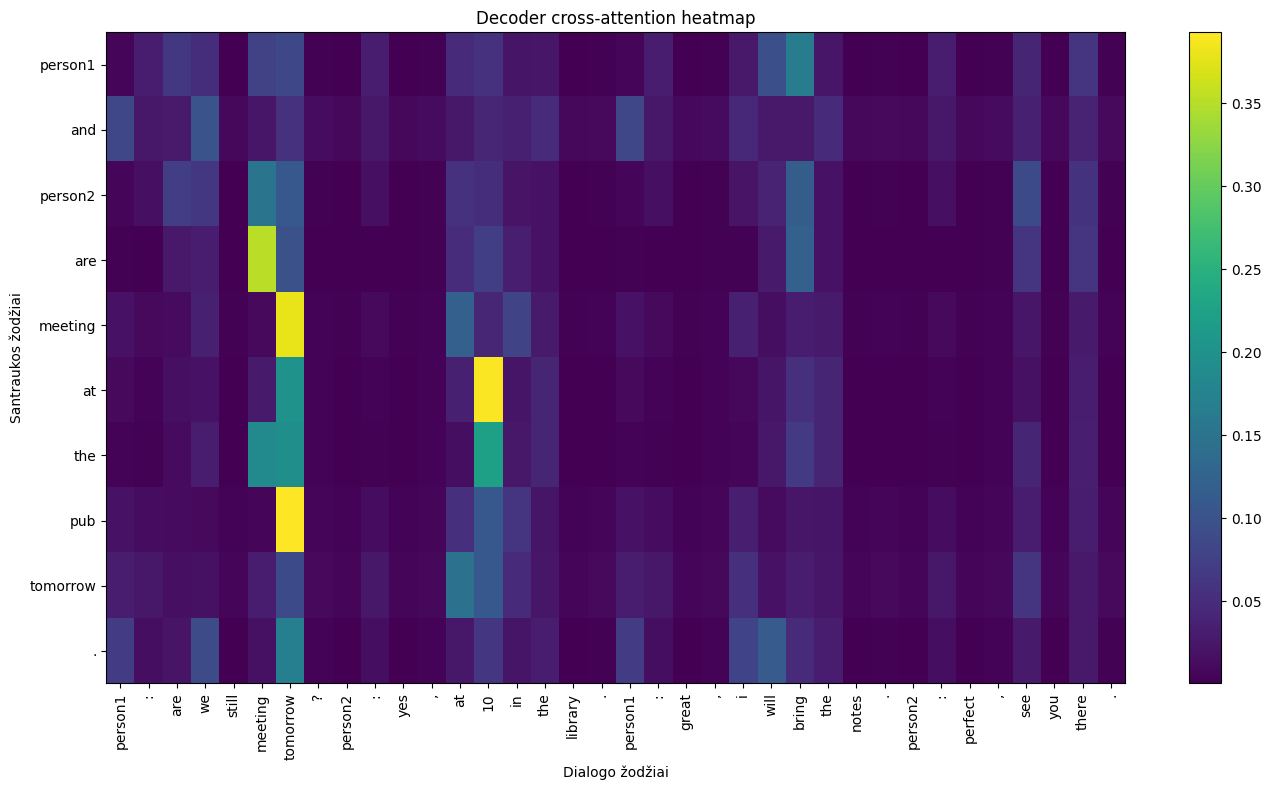

In [ ]:
# 33. Attention heatmap pavyzdžio sugeneravimas

example_text = """Person1: Are we still meeting tomorrow? Person2: Yes, at 10 in the library. Person1: Great, I will bring the notes. Person2: Perfect, see you there. """


attn, src_labels, tgt_labels, pred = get_cross_attention_for_example(
    loaded_model, loaded_vocab, example_text, cfg
)

print("Sugeneruota santrauka:")
print(pred)

plot_attention_heatmap(attn, src_labels, tgt_labels)

### 34. Testavimo metrikų išvedimas
Šioje celėje iš `metrics.json` failo įkeliamos galutinės testavimo metrikos ir jos atspausdinamos ekrane. 

In [ ]:
#34. testo metriku isvedimas
metrics_path = Path(cfg.output_dir) / "test" / "metrics.json"

with open(metrics_path, "r", encoding="utf-8") as f:
    test_metrics = json.load(f)

print("TEST METRICS")
for key, value in test_metrics.items():
    print(f"{key}: {value}")

TEST METRICS
num_samples: 819
rouge1_f1_mean: 0.2896360246395877
rouge2_f1_mean: 0.06491186632494081
rougeL_f1_mean: 0.22797657952991923
rouge1_precision_mean: 0.4126099055698778
rouge1_recall_mean: 0.2487620091454408
rouge2_precision_mean: 0.09481548551522696
rouge2_recall_mean: 0.05542156271527779
rougeL_precision_mean: 0.3229097521038334
rougeL_recall_mean: 0.19699446220318464
source_words_mean: 95.5079365079365
reference_words_mean: 20.00976800976801
prediction_words_mean: 12.702075702075701
bertscore_precision_mean: 0.6453893184661865
bertscore_recall_mean: 0.5564705729484558
bertscore_f1_mean: 0.5953725576400757


### 35. Įvesties ilgio ir BERTScore ryšio analizė
Čia apskaičiuojamas kiekvieno dialogo ilgis žodžiais ir tikrinama, kaip jis susijęs su BERTScore F1 rezultatu. 

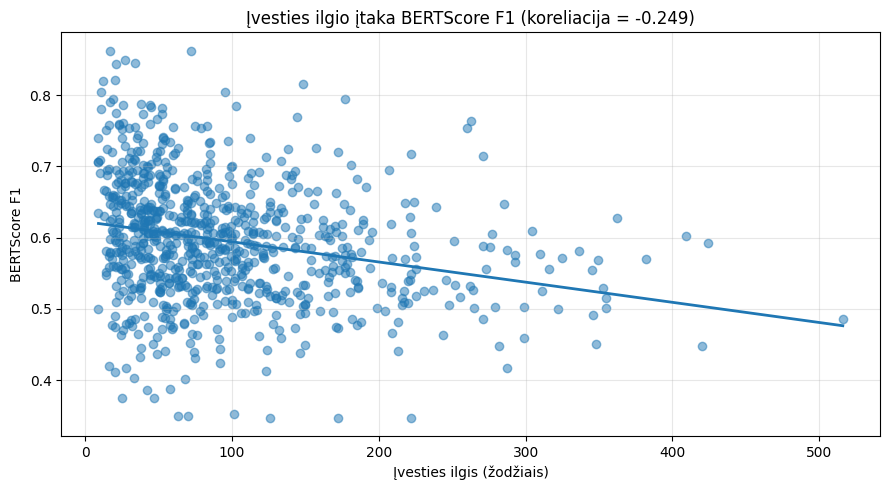

Koreliacija tarp įvesties ilgio ir BERTScore F1: -0.2491


In [ ]:
# 35. Įvesties ilgio ir BERTScore ryšio analizė

df = test_predictions.copy()

# Apskaičiuojam įvesties ilgį žodžiais
df["input_length_words"] = df["source_text"].fillna("").astype(str).apply(lambda x: len(x.split()))

# Koreliacija
corr = df["input_length_words"].corr(df["bertscore_f1"])

plt.figure(figsize=(9, 5))
plt.scatter(df["input_length_words"], df["bertscore_f1"], alpha=0.5)

# Tendencijos linija
z = np.polyfit(df["input_length_words"], df["bertscore_f1"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["input_length_words"].min(), df["input_length_words"].max(), 200)
plt.plot(x_line, p(x_line), linewidth=2)

plt.xlabel("Įvesties ilgis (žodžiais)")
plt.ylabel("BERTScore F1")
plt.title(f"Įvesties ilgio įtaka BERTScore F1 (koreliacija = {corr:.3f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Koreliacija tarp įvesties ilgio ir BERTScore F1: {corr:.4f}")

### 36. BERTScore F1 pasiskirstymo histograma
Šioje celėje nubraižoma BERTScore F1 reikšmių histograma testavimo aibėje.

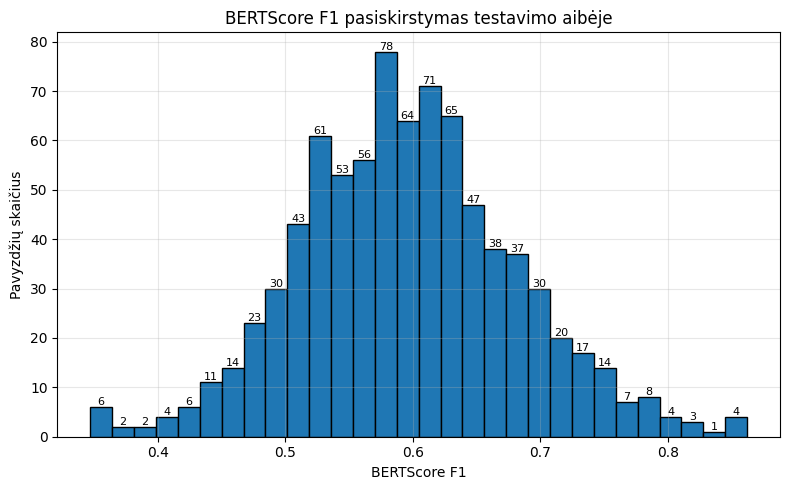

Santrauka apie BERTScore F1 pasiskirstymą:
count    819.000000
mean       0.595373
std        0.085439
min        0.347151
25%        0.536531
50%        0.592748
75%        0.646281
max        0.862236
Name: bertscore_f1, dtype: float64


In [ ]:
# 36. BERTScore F1 pasiskirstymo histograma

df = test_predictions.copy()

plt.figure(figsize=(8, 5))

counts, bins, patches = plt.hist(
    df["bertscore_f1"].dropna(),
    bins=30,
    edgecolor="black"
)

for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        x = (bin_left + bin_right) / 2
        y = count
        plt.text(x, y, int(count), ha='center', va='bottom', fontsize=8)

plt.xlabel("BERTScore F1")
plt.ylabel("Pavyzdžių skaičius")
plt.title("BERTScore F1 pasiskirstymas testavimo aibėje")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Santrauka apie BERTScore F1 pasiskirstymą:")
print(df["bertscore_f1"].describe())

### 37. Geriausios ir blogiausios santraukos pagal BERTScore
Čia surandamas geriausias ir blogiausias testavimo pavyzdys pagal BERTScore F1 reikšmę. Atspausdinama įvestis, etaloninė santrauka ir modelio sugeneruota santrauka.

In [ ]:
# 37. Geriausios ir blogiausios santraukos pagal BERTScore

best_row = df.loc[df["bertscore_f1"].idxmax()]

print("GERIAUSIA SANTRAUKA PAGAL BERTScore F1")
print("=" * 80)
print(f"BERTScore F1: {best_row['bertscore_f1']:.4f}")
print("\nĮVESTIS:")
print(best_row["source_text"])
print("\nETALONINĖ SANTRAUKA:")
print(best_row["reference_summary"])
print("\nMODELIO SANTRAUKA:")
print(best_row["predicted_summary"])

worst_row = df.loc[df["bertscore_f1"].idxmin()]

print("BLOGIAUSIA SANTRAUKA PAGAL BERTScore F1")
print("=" * 80)
print(f"BERTScore F1: {worst_row['bertscore_f1']:.4f}")
print("\nĮVESTIS:")
print(worst_row["source_text"])
print("\nETALONINĖ SANTRAUKA:")
print(worst_row["reference_summary"])
print("\nMODELIO SANTRAUKA:")
print(worst_row["predicted_summary"])

mean_score = df["bertscore_f1"].mean()
df["distance_to_mean"] = (df["bertscore_f1"] - mean_score).abs()

avg_row = df.loc[df["distance_to_mean"].idxmin()]

print("VIDUTINĖ SANTRAUKA PAGAL BERTScore F1")
print("=" * 80)
print(f"Testo rinkinio BERTScore F1 vidurkis: {mean_score:.4f}")
print(f"Pasirinkto pavyzdžio BERTScore F1: {avg_row['bertscore_f1']:.4f}")

print("\nĮVESTIS:")
print(avg_row["source_text"])
print("\nETALONINĖ SANTRAUKA:")
print(avg_row["reference_summary"])
print("\nMODELIO SANTRAUKA:")
print(avg_row["predicted_summary"])

GERIAUSIA SANTRAUKA PAGAL BERTScore F1
BERTScore F1: 0.8622

ĮVESTIS:
Jerry: Hi sweetie :) Janet: Hi sugar ;) Jerry: I'm coming home Janet: Can't wait ;) Jerry: I should be there in 40 minutes Janet: Ok, I'm waiting for you :) Jerry: How was your day? Janet: Oh, it was ok but my boss is a pain in the ass sometimes Jerry: I know, she can be a bitch :P Janet: Yes she can! ;) Jerry: See you later darling Janet: <3

ETALONINĖ SANTRAUKA:
Person1 will be home in 40 minutes.

MODELIO SANTRAUKA:
person1 is waiting for person2 . person2 will be home in 20 minutes .
BLOGIAUSIA SANTRAUKA PAGAL BERTScore F1
BERTScore F1: 0.3472

ĮVESTIS:
Cora: Have you heard how much fuss British media made about meet and greet with James Charles in Birmingham? Ellie: no...! what happened? Cora: Well, there was a meet and greet with James Charles in one of the malls in Birmingham and about 8000 fans showed up for it. Cora: It cause a gridlock around the mall and - of course - British media had to make some (quite 